<a href="https://colab.research.google.com/github/anaguilarar/WeatherSoilDataProcessor/blob/main/google_colab_examples/taller_simulacion_cultivo_honduras.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<a href="https://colab.research.google.com/github/anaguilarar/WeatherSoilDataProcessor/blob/main/google_colab_examples/taller_simulacion_cultivo_honduras.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Simulación espacial de cultivos con DSSAT
## Taller práctico &mdash; Aldea San Isidro (Victoria, Yoro, Honduras)

En este cuaderno vamos a **simular el rendimiento potencial de maíz** dentro de una
aldea de Honduras, píxel por píxel, usando el modelo de cultivo
[DSSAT](https://dssat.net/) y la librería
[WeatherSoilDataProcessor](https://github.com/anaguilarar/WeatherSoilDataProcessor).

**La pregunta que queremos responder es:**

> *Si sembramos maíz en esta aldea, ¿cuánto podría rendir y en qué fecha conviene sembrar?*

---

### Cómo funciona una simulación de cultivo

Un modelo de cultivo es un programa que reproduce, día a día, el crecimiento de una
planta. Para hacerlo necesita tres cosas:

| Ingrediente | Qué responde | De dónde sale en este taller |
|---|---|---|
| **Clima diario** | Cuánta lluvia, sol y calor recibe el cultivo | CHIRPS + AgERA5 (1990&ndash;2024) |
| **Suelo** | Cuánta agua y nutrientes puede almacenar el terreno | SoilGrids (4 profundidades) |
| **Manejo** | Qué se siembra, cuándo y con qué fertilización | Lo definimos nosotros |

El modelo se corre **una vez por cada píxel** del mapa y **una vez por cada año de
clima disponible**. Así obtenemos, en lugar de un único número, un mapa de
rendimiento y una idea de cuánto varía ese rendimiento entre años buenos y años malos.

---

### Lo que haremos, paso a paso

0. Instalar la librería en Colab
1. Elegir la aldea a simular
2. Definir la configuración de la simulación (cultivo, fechas, manejo)
3. Descargar el clima y el suelo ya recortados para esa aldea
4. Generar los archivos de entrada de DSSAT
5. Correr el modelo
6. Ver e interpretar los resultados

> **Nota:** varias celdas aparecen como una barra con un título y un botón de
> ejecución. Ese código está oculto a propósito (instalaciones, descargas,
> gráficos) para que nos concentremos en lo importante. Si quieres verlo, haz
> doble clic sobre el título de la celda.


---
## Paso 0. Preparar el entorno de Colab

Descargamos el código de la librería y sus dependencias. Toma unos 3 minutos y
solo hay que ejecutarlo una vez por sesión.


In [1]:
# @title Instalar WeatherSoilDataProcessor (~3 min) { display-mode: "form" }
# @markdown Ejecuta esta celda y espera el mensaje **Entorno listo**.
import os, subprocess, sys

REPO_DIR = "/content/WeatherSoilDataProcessor"

if not os.path.exists(REPO_DIR):
    print("Descargando el código...")
    subprocess.run(["git", "clone", "-q",
                    "https://github.com/anaguilarar/WeatherSoilDataProcessor.git",
                    REPO_DIR], check=True)

os.chdir(REPO_DIR)

print("Instalando dependencias (puede tardar ~3 min)...")
subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r",
                os.path.join(REPO_DIR, "requirements.txt")], check=True)

import warnings
warnings.filterwarnings("ignore")
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

import os, subprocess, sys
os.environ["PYTHONWARNINGS"] = "ignore"

print("\nEntorno listo. Carpeta de trabajo:", os.getcwd())


Descargando el código...
Instalando dependencias (puede tardar ~3 min)...

Entorno listo. Carpeta de trabajo: /content/WeatherSoilDataProcessor


---
## Paso 1. La zona de estudio

Honduras está dividida en **aldeas**, la unidad administrativa más pequeña del país.
El repositorio incluye el mapa oficial de aldeas en `data/tb_limitealdeas.shp`,
donde cada una tiene un código único en la columna `GEOCODIGO`.

Para el taller trabajaremos con la aldea **181017**. Cambiando ese código puedes
repetir todo el ejercicio en cualquier otra aldea del país.


In [2]:
import geopandas as gpd

CODIGO_ALDEA = "181017"          # <-- código de la aldea a simular

aldeas = gpd.read_file("data/tb_limitealdeas.shp")
aldea  = aldeas.loc[aldeas["GEOCODIGO"] == CODIGO_ALDEA]

aldea[["GEOCODIGO", "ALDEA", "MUNI", "DEPTO", "AREA_HA"]]


,GEOCODIGO,ALDEA,MUNI,DEPTO,AREA_HA
1336,181017,San Isidro,Victoria,Yoro,7229.212391


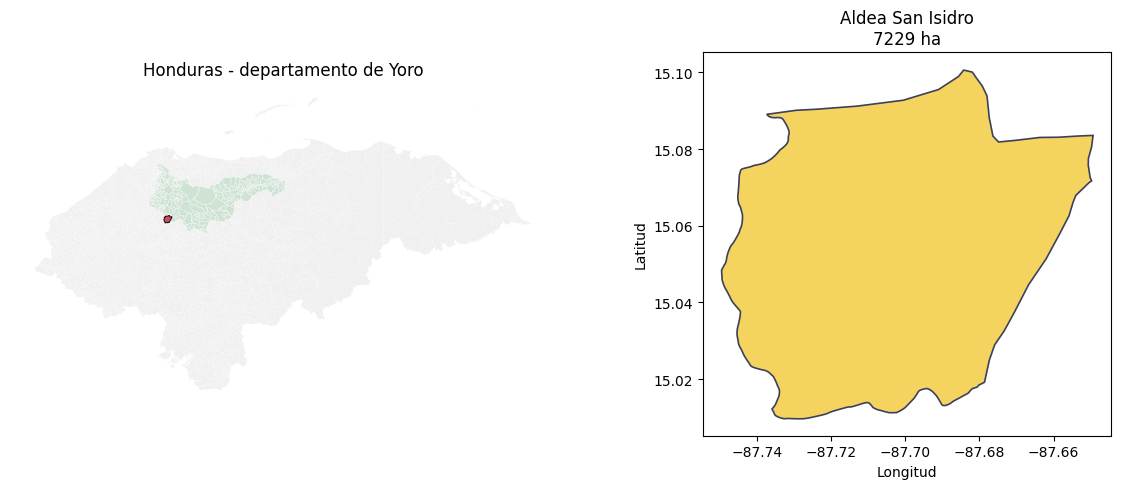

In [3]:
# @title Ver la aldea en el mapa { display-mode: "form" }
import matplotlib.pyplot as plt

depto = aldeas.loc[aldeas["DEPTO"] == aldea["DEPTO"].values[0]]

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

aldeas.plot(ax=ax[0], color="#f0f0f0", edgecolor="white", linewidth=0.1)
depto.plot(ax=ax[0], color="#cfe3d4", edgecolor="white", linewidth=0.2)
aldea.plot(ax=ax[0], color="#d1495b", edgecolor="black", linewidth=0.6)
ax[0].set_title("Honduras - departamento de " + aldea["DEPTO"].values[0])
ax[0].set_axis_off()

aldea.plot(ax=ax[1], facecolor="#f4d35e", edgecolor="#3d405b", linewidth=1.2)
ax[1].set_title("Aldea %s\n%d ha" % (aldea["ALDEA"].values[0],
                                     round(aldea["AREA_HA"].values[0])))
ax[1].set_xlabel("Longitud"); ax[1].set_ylabel("Latitud")

plt.tight_layout()
plt.show()


---
## Paso 2. Configurar la simulación

Toda la simulación se controla desde **un solo diccionario de configuración**.
Es el bloque más importante del taller, así que vale la pena leerlo con calma.
Tiene cuatro secciones:

* **`GENERAL_INFO`** &rarr; qué modelo usar y dónde se guardan los resultados.
* **`SPATIAL_INFO`** &rarr; qué archivo de límites usar y a qué escala simular.
  Con `aggregate_by: "pixel"` le decimos al sistema que corra el modelo de forma
  independiente en **cada píxel** del mapa; así obtenemos mapas y no un solo
  promedio para toda la aldea.
* **`CROP`** &rarr; el cultivo y la variedad. `IB1072` es un maíz de ciclo medio
  incluido por defecto en DSSAT.
* **`MANAGEMENT`** &rarr; el manejo agronómico: fecha de siembra, fecha límite de
  cosecha, cuántas fechas de siembra alternativas probar y si se fertiliza o no.

### Tres parámetros que definen cuánto tarda el ejercicio

* **`ANIO_INICIO`**: el clima disponible va de 1990 a 2024. El modelo simula una
  temporada por cada año desde `ANIO_INICIO` (el clima del último año se usa para
  cerrar el ciclo del año anterior). Con 2019 son **5 temporadas, de 2019 a 2023**:
  suficiente para ver variabilidad entre años sin esperar demasiado.
* **`VENTANAS_DE_SIEMBRA`**: cuántas fechas de siembra alternativas probar,
  separadas por una semana cada una. Con 3, el modelo prueba sembrar el 1, el 8
  y el 15 de mayo.
* **`FACTOR_RESOLUCION`**: reduce la resolución espacial para que la práctica
  corra en pocos minutos. Con 1 se usa la resolución original (~550 m) y hay
  muchos más píxeles que simular; con 2 los píxeles pasan a ~1.1 km.


In [9]:
warnings.filterwarnings("ignore")
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

ANIO_INICIO         = 2019   # primer año de clima a simular (el último disponible es 2024)
VENTANAS_DE_SIEMBRA = 3      # número de fechas de siembra a probar (una por semana)
FACTOR_RESOLUCION   = 3      # 1 = ~550 m (lento) | 2 = ~1.1 km (recomendado) | 3 = ~1.6 km

configuracion = {

    "GENERAL_INFO": {
        "country": "Honduras",
        "country_code": "HND",
        "working_path": "runs",     # carpeta donde se escriben los archivos del modelo
        "model": "dssat",           # modelo de cultivo a utilizar
        "ncores": 10,                # simulaciones en paralelo
        "bin_path": None,           # None = usar el DSSAT que trae la librería
    },

    "SPATIAL_INFO": {
        "geospatial_path": "data/tb_limitealdeas.shp",  # mapa de aldeas
        "feature_name": "GEOCODIGO",                    # columna con el código de la aldea
        "aggregate_by": "pixel",                        # simular píxel por píxel
        "soil_path": None,        # los datacubos recortados se cargan en el Paso 3
        "weather_path": None,
        "scale_factor": 1,
    },

    "CROP": {
        "name": "Maize",          # cultivo
        "cultivar": "IB1072",     # variedad de maíz de ciclo medio
        "cultivar_file": None,
    },

    "MANAGEMENT": {
        "planting_date":   "%d-05-01" % ANIO_INICIO,   # inicio de la época de siembra
        "harvesting_date": "%d-10-30" % ANIO_INICIO,   # fecha límite de cosecha
        "plantingWindow": VENTANAS_DE_SIEMBRA,         # fechas de siembra a evaluar
        "fertilizer_schedule": {                       # sin fertilización: el rendimiento
            "days_after_planting": None,               # queda limitado por el agua y el suelo
            "npk": None,
        },
        "index_soilwat": 1,
        "template": "crop_modeling/dssat/exp_files/KEAG8104.MZX",  # experimento base
    },
}

print("Cultivo    :", configuracion["CROP"]["name"], "-", configuracion["CROP"]["cultivar"])
print("Aldea      :", CODIGO_ALDEA)
print("Temporadas :", 2024 - ANIO_INICIO, "(de %d a %d)" % (ANIO_INICIO, 2023))
print("Siembras   :", VENTANAS_DE_SIEMBRA, "fechas desde el", configuracion["MANAGEMENT"]["planting_date"])


Cultivo    : Maize - IB1072
Aldea      : 181017
Temporadas : 5 (de 2019 a 2023)
Siembras   : 3 fechas desde el 2019-05-01


---
## Paso 3. Los datos de clima y suelo

Construir los datacubos de clima y suelo para todo Honduras toma horas de descarga
y procesamiento (ese proceso completo está en el cuaderno
[`dssat_spatial_crop_simulation_pixel.ipynb`](https://github.com/anaguilarar/WeatherSoilDataProcessor/blob/main/google_colab_examples/dssat_spatial_crop_simulation_pixel.ipynb)).
Para este taller ya están **recortados a la aldea** y guardados en Google Drive:

* **`weather_.nc`** &rarr; lluvia, radiación solar, temperatura máxima y mínima,
  viento y presión de vapor, **para cada día entre 1990 y 2024**.
  Fuentes: [CHIRPS](https://www.chc.ucsb.edu/data/chirps) (lluvia) y
  [AgERA5](https://cds.climate.copernicus.eu/datasets/sis-agrometeorological-indicators)
  (las demás variables).
* **`soil_.nc`** &rarr; arena, limo, arcilla, carbono orgánico, pH, capacidad de
  intercambio catiónico y retención de humedad, en **4 profundidades**
  (0&ndash;5, 5&ndash;15, 15&ndash;30 y 30&ndash;60 cm).
  Fuente: [SoilGrids](https://soilgrids.org/).

La siguiente celda los descarga, los deja en la carpeta de trabajo de la aldea y
los prepara: descomprime los valores, recorta la serie climática a partir de
`ANIO_INICIO` y ajusta la resolución según `FACTOR_RESOLUCION`.


In [10]:
# @title Descargar y preparar los datos de la aldea { display-mode: "form" }
# @markdown Descarga los datacubos desde Google Drive y los deja listos para el modelo.
import os, shutil
import numpy as np
import xarray as xr
warnings.filterwarnings("ignore")
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

from crop_modeling.spatial_process import SpatialCM, SpatialData
from spatialdata.utils import read_compressed_xarray

ID_DRIVE_CLIMA = "1uFC20Hnc9LXzyu1C7p4FfZOOOmH5xgxk"
ID_DRIVE_SUELO = "1VL-eMx-idHuqtzjKrfkfMzy6DWXH5Fbo"

# 1) descargar una sola vez a una carpeta de caché
os.makedirs("datos_aldea", exist_ok=True)
if not os.path.exists("datos_aldea/weather_.nc"):
    !gdown -q {ID_DRIVE_CLIMA} -O datos_aldea/weather_.nc
if not os.path.exists("datos_aldea/soil_.nc"):
    !gdown -q {ID_DRIVE_SUELO} -O datos_aldea/soil_.nc

# 2) crear el objeto que orquesta la simulación, y su carpeta de trabajo
shutil.rmtree(os.path.join("runs", CODIGO_ALDEA), ignore_errors=True)
simulacion = SpatialCM(configuration_dict=configuracion, load_env_data=False)
simulacion.set_up_folders(site=CODIGO_ALDEA)

# 3) copiar los datacubos a la carpeta de la aldea y descomprimirlos
shutil.copy2("datos_aldea/weather_.nc", simulacion._weather_tmppath)
shutil.copy2("datos_aldea/soil_.nc",    simulacion._soil_tmppath)
read_compressed_xarray(simulacion._weather_tmppath, simulacion._tmp_path)
read_compressed_xarray(simulacion._soil_tmppath,    simulacion._tmp_path)

# 4) recortar la serie climática y ajustar la resolución espacial
clima = xr.load_dataset(simulacion._weather_tmppath)
suelo = xr.load_dataset(simulacion._soil_tmppath)

clima = clima.isel(date=np.where(clima.date.values >= "%d0101" % ANIO_INICIO)[0])

if FACTOR_RESOLUCION > 1:
    escala = dict(x=FACTOR_RESOLUCION, y=FACTOR_RESOLUCION, boundary="trim")
    clima = clima.coarsen(**escala).mean()
    suelo = suelo.coarsen(**escala).mean()

SpatialData()._save_asnc(clima, simulacion._weather_tmppath)
SpatialData()._save_asnc(suelo, simulacion._soil_tmppath)

resolucion = abs(float(clima.x[1] - clima.x[0]))
print("Clima : %d días (%s a %s)" % (len(clima.date), clima.date.values[0], clima.date.values[-1]))
print("Suelo : %d profundidades -> %s" % (len(suelo.depth), [str(d) for d in suelo.depth.values]))
print("Malla : %d x %d píxeles de ~%d m" % (len(clima.y), len(clima.x), resolucion))
print("Carpeta de trabajo:", simulacion._tmp_path)


Clima : 2192 días (20190101 a 20241231)
Suelo : 4 profundidades -> ['0-5', '5-15', '15-30', '30-60']
Malla : 6 x 6 píxeles de ~1680 m
Carpeta de trabajo: runs/181017


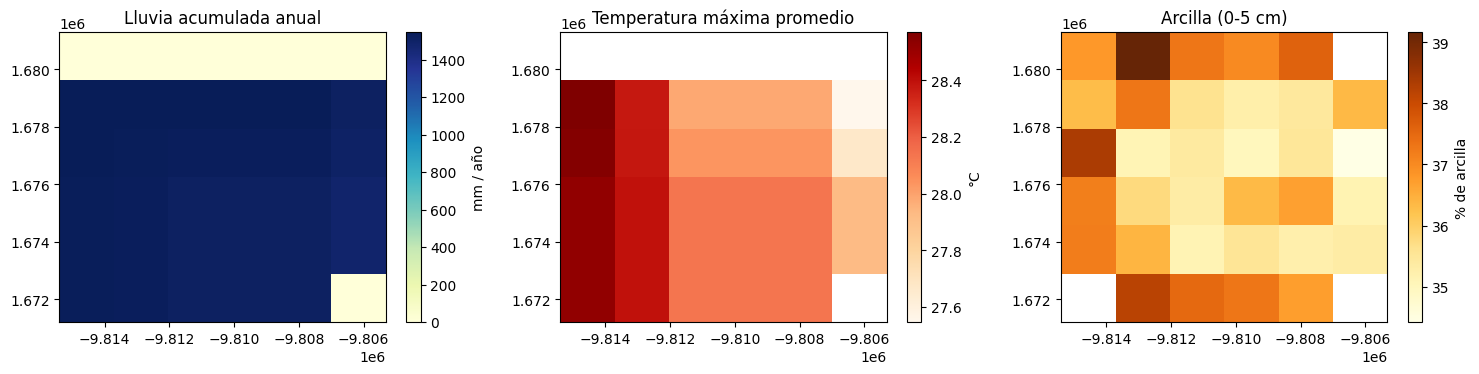

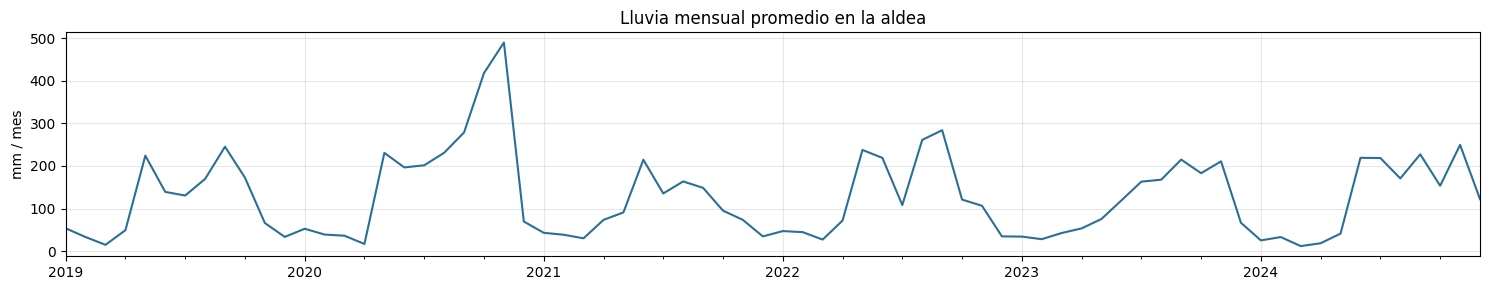

In [8]:
# @title Ver los datos de entrada { display-mode: "form" }
import matplotlib.pyplot as plt
import pandas as pd

fechas_clima = pd.to_datetime(pd.Series(clima.date.values), format="%Y%m%d")
n_anios = fechas_clima.dt.year.nunique()

fig, ax = plt.subplots(1, 3, figsize=(15, 4))

(clima.precipitation.sum(dim="date") / n_anios).plot(
    ax=ax[0], cmap="YlGnBu", cbar_kwargs={"label": "mm / año"})
ax[0].set_title("Lluvia acumulada anual")

clima.tmax.mean(dim="date").plot(
    ax=ax[1], cmap="OrRd", cbar_kwargs={"label": "°C"})
ax[1].set_title("Temperatura máxima promedio")

(suelo.clay.sel(depth="0-5") / 10).plot(
    ax=ax[2], cmap="YlOrBr", cbar_kwargs={"label": "% de arcilla"})
ax[2].set_title("Arcilla (0-5 cm)")

for a in ax:
    a.set_xlabel(""); a.set_ylabel("")
plt.tight_layout()
plt.show()

serie = clima.precipitation.mean(dim=["x", "y"]).to_series()
serie.index = pd.to_datetime(serie.index, format="%Y%m%d")
fig, ax = plt.subplots(figsize=(15, 3))
serie.resample("MS").sum().plot(ax=ax, color="#2a6f97")
ax.set_title("Lluvia mensual promedio en la aldea")
ax.set_ylabel("mm / mes"); ax.set_xlabel("")
ax.grid(alpha=.3)
plt.tight_layout()
plt.show()


---
## Paso 4. Generar los archivos de entrada de DSSAT

DSSAT no lee archivos NetCDF: necesita sus propios formatos de texto. Por cada
píxel de la aldea hay que escribir tres archivos:

| Archivo | Contenido |
|---|---|
| `WTHE0001.WTH` | La serie climática diaria de ese píxel |
| `TR.SOL` | El perfil de suelo de ese píxel, capa por capa |
| `EXP*.MZX` | El experimento: cultivo, variedad, fechas de siembra y manejo |

La librería hace toda esa traducción por nosotros. Esta es la parte más lenta del
taller &mdash; unos **3 a 5 minutos** con `FACTOR_RESOLUCION = 2` &mdash; porque se
repite para cada píxel. Es buen momento para revisar el diccionario del Paso 2.


In [11]:
# 1) traducir los datacubos a archivos de DSSAT, un píxel a la vez
carpeta_trabajo = simulacion.create_roi_sp_data(roi=aldea, export_spatial_data=False)

# 2) localizar las carpetas creadas (una por píxel)
simulacion.model.find_envworking_paths(simulacion._tmp_path, "WTH")
print("\nPíxeles a simular:", len(simulacion.model._process_paths))

# 3) escribir el archivo del cultivo y el del manejo en cada carpeta
simulacion.model.set_up_crop(crop=simulacion.crop,
                             cultivar=simulacion.cultivar)
simulacion.model.set_up_management(crop=simulacion.crop,
                                   cultivar=simulacion.cultivar,
                                   **simulacion.config.MANAGEMENT)
print("Archivos de DSSAT listos en:", carpeta_trabajo)


100%|██████████| 33/33 [00:38<00:00,  1.18s/it]



Píxeles a simular: 33
Configuration file written: runs/181017/28/experimental_file_config.yaml
experimental file created: ['runs/181017/28/EXPS0001.MZX']
Configuration file written: runs/181017/36/experimental_file_config.yaml
experimental file created: ['runs/181017/36/EXPS0001.MZX']
Configuration file written: runs/181017/12/experimental_file_config.yaml
experimental file created: ['runs/181017/12/EXPS0001.MZX']
Configuration file written: runs/181017/22/experimental_file_config.yaml
experimental file created: ['runs/181017/22/EXPS0001.MZX']
Configuration file written: runs/181017/10/experimental_file_config.yaml
experimental file created: ['runs/181017/10/EXPS0001.MZX']
Configuration file written: runs/181017/40/experimental_file_config.yaml
experimental file created: ['runs/181017/40/EXPS0001.MZX']
Configuration file written: runs/181017/33/experimental_file_config.yaml
experimental file created: ['runs/181017/33/EXPS0001.MZX']
Configuration file written: runs/181017/21/experiment

---
## Paso 5. Correr el modelo

Ahora sí ejecutamos DSSAT. Para cada píxel el modelo corre una simulación por
cada fecha de siembra y, dentro de cada una, una temporada por cada año de clima.

Es decir: `píxeles x fechas de siembra x años` simulaciones de cultivo.


In [12]:
resultado_corridas = simulacion.model.run(
    simulacion.model.crop_code,
    crop=simulacion.crop,
    planting_window=simulacion.config.MANAGEMENT.plantingWindow,
    ncores=simulacion.config.GENERAL_INFO.ncores,
    bin_path=simulacion.config.GENERAL_INFO.bin_path,
    remove_tmp_folder=True,
)

exitosos = sum(resultado_corridas.values())
print("\nPíxeles simulados correctamente: %d de %d" % (exitosos, len(resultado_corridas)))


100%|██████████| 33/33 [00:29<00:00,  1.11it/s]


Píxeles simulados correctamente: 33 de 33


---
## Paso 6. Leer e interpretar los resultados

DSSAT deja sus resultados en archivos de texto (`Summary.OUT`), uno por píxel.
Los leemos todos y los volvemos a armar como un mapa.

La variable que nos interesa es **`HWAH`**: el rendimiento en grano a la cosecha,
en **kg/ha**.

Construimos dos productos:

* **`rendimiento`**: un mapa por cada combinación de fecha de siembra y año, para
  ver la variabilidad entre temporadas.
* **`rendimiento_promedio`**: el promedio de todos los años para cada fecha de
  siembra. Este es el que responde la pregunta *"¿cuándo conviene sembrar?"*.


In [13]:
import os
import pandas as pd
import rioxarray as rio
from crop_modeling.dssat.output import update_dssat_data_using_path
from crop_modeling.spatial_process import create_mlt_yield_raster
from crop_modeling.utils.output_transforms import summarize_spatial_yields_by_time_window

raster_ref = rio.open_rasterio(os.path.join(simulacion._tmp_path, "ref_raster.tif"))
salidas    = update_dssat_data_using_path(simulacion._tmp_path)

# un mapa por cada fecha de siembra simulada (fechas de siembra x años)
rendimiento = create_mlt_yield_raster(raster_ref, salidas, ycol_name="HWAH")

# promedio entre años, para cada una de las fechas de siembra
rendimiento_promedio = summarize_spatial_yields_by_time_window(
    rendimiento, plantingWindow=VENTANAS_DE_SIEMBRA)

# cada ventana de siembra se repite en todos los años; las etiquetamos 1, 2, 3...
fechas_simuladas = sorted(pd.to_datetime(rendimiento.date.values))
ventana_de_fecha = {f: i % VENTANAS_DE_SIEMBRA for i, f in enumerate(fechas_simuladas)}
etiquetas_siembra = {}
for fecha, ventana in ventana_de_fecha.items():
    etiquetas_siembra.setdefault(ventana, "Siembra %d (%s)" % (ventana + 1, fecha.strftime("%d-%b")))
orden_siembras = [etiquetas_siembra[v] for v in sorted(etiquetas_siembra)]

print("Temporadas simuladas :", len(fechas_simuladas) // VENTANAS_DE_SIEMBRA,
      "(%d a %d)" % (fechas_simuladas[0].year, fechas_simuladas[-1].year))
print("Fechas de siembra    :", orden_siembras)
print("Mapas de rendimiento :", dict(rendimiento.sizes))


100%|██████████| 15/15 [00:00<00:00, 163.04it/s]

Temporadas simuladas : 5 (2019 a 2023)
Fechas de siembra    : ['Siembra 1 (01-May)', 'Siembra 2 (08-May)', 'Siembra 3 (15-May)']
Mapas de rendimiento : {'date': 15, 'y': 6, 'x': 7}


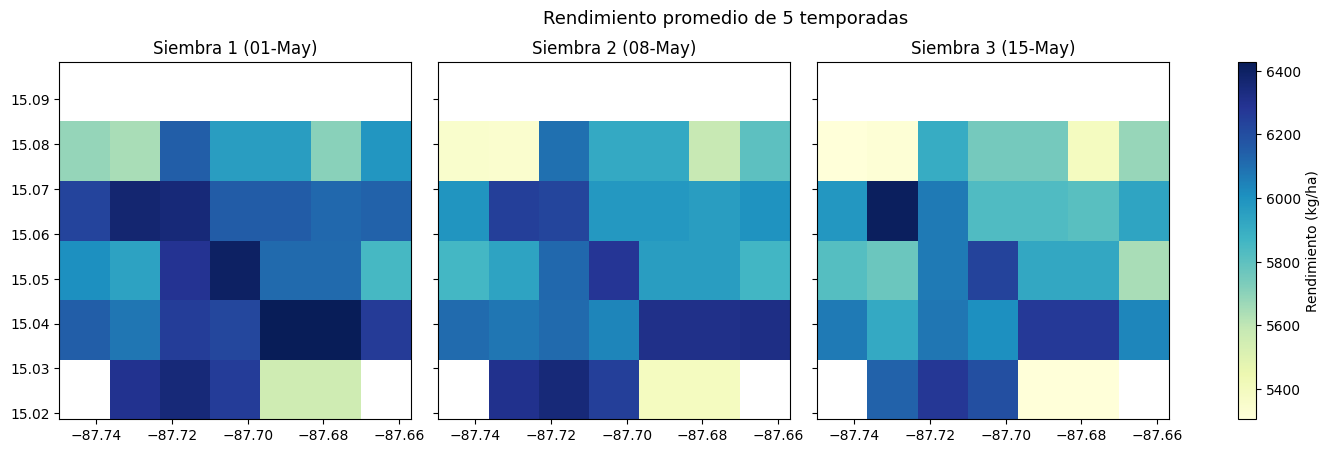

In [14]:
# @title Mapa del rendimiento promedio por fecha de siembra { display-mode: "form" }
import matplotlib.pyplot as plt

n_col = min(3, len(orden_siembras))

g = rendimiento_promedio.HWAH.plot(
    x="x", y="y", col="date", col_wrap=n_col,
    cmap="YlGnBu", figsize=(5 * n_col, 4.5),
    cbar_kwargs={"label": "Rendimiento (kg/ha)"})

for ax, nombre in zip(g.axes.flat, orden_siembras):
    ax.set_title(nombre)
    ax.set_xlabel(""); ax.set_ylabel("")

plt.suptitle("Rendimiento promedio de %d temporadas" % (len(fechas_simuladas) // VENTANAS_DE_SIEMBRA),
             y=1.04, fontsize=13)
plt.show()


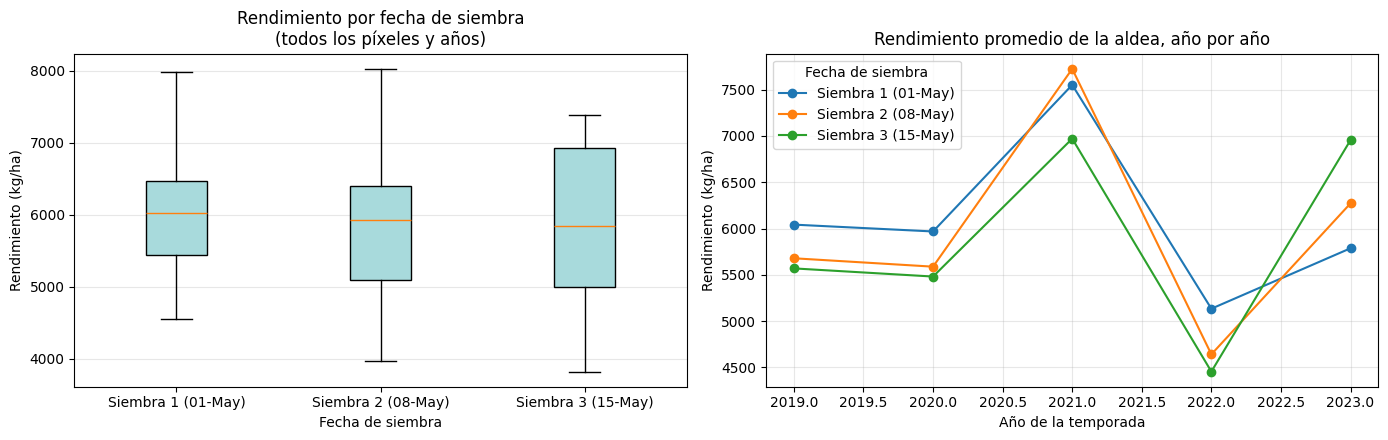


Rendimiento (kg/ha) por fecha de siembra:
                    promedio  minimo  maximo
siembra                                     
Siembra 1 (01-May)    6096.0  4560.0  7984.0
Siembra 2 (08-May)    5981.0  3977.0  8023.0
Siembra 3 (15-May)    5886.0  3825.0  7386.0

Mejor fecha de siembra en promedio: Siembra 1 (01-May)


In [15]:
# @title Comparar las fechas de siembra { display-mode: "form" }
import matplotlib.pyplot as plt
import pandas as pd

tabla = rendimiento.HWAH.to_dataframe().reset_index().dropna(subset=["HWAH"])
tabla["fecha"] = pd.to_datetime(tabla["date"])
tabla["siembra"] = tabla["fecha"].map(ventana_de_fecha).map(etiquetas_siembra)
tabla["anio"] = tabla["fecha"].dt.year

orden = orden_siembras
datos = [tabla.loc[tabla["siembra"] == f, "HWAH"].values for f in orden]

fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))

caja = ax[0].boxplot(datos, patch_artist=True)
ax[0].set_xticklabels(orden)
for p in caja["boxes"]:
    p.set_facecolor("#a8dadc")
ax[0].set_title("Rendimiento por fecha de siembra\n(todos los píxeles y años)")
ax[0].set_ylabel("Rendimiento (kg/ha)")
ax[0].set_xlabel("Fecha de siembra")
ax[0].grid(axis="y", alpha=.3)

pivote = tabla.pivot_table(index="anio", columns="siembra",
                           values="HWAH", aggfunc="mean")[orden]
pivote.plot(ax=ax[1], marker="o")
ax[1].set_title("Rendimiento promedio de la aldea, año por año")
ax[1].set_ylabel("Rendimiento (kg/ha)")
ax[1].set_xlabel("Año de la temporada")
ax[1].legend(title="Fecha de siembra")
ax[1].grid(alpha=.3)

plt.tight_layout()
plt.show()

resumen = (tabla.groupby("siembra")["HWAH"]
                .agg(promedio="mean", minimo="min", maximo="max")
                .reindex(orden).round(0))
print("\nRendimiento (kg/ha) por fecha de siembra:")
print(resumen)
print("\nMejor fecha de siembra en promedio:", resumen["promedio"].idxmax())


### Cómo leer estos resultados

* El **mapa** muestra dónde el terreno responde mejor. Dentro de una aldea el
  clima es prácticamente el mismo, así que las diferencias entre píxeles vienen
  sobre todo del suelo: textura, profundidad y capacidad de retener agua.
* El **diagrama de cajas** resume todos los píxeles y todos los años de cada
  fecha de siembra. Una caja alta significa buen rendimiento; una caja larga
  significa mucho riesgo, porque el resultado depende fuertemente del año.
* La **línea por año** muestra la variabilidad climática: los años secos hunden
  el rendimiento de todas las fechas de siembra al mismo tiempo.

Recuerda que estamos simulando **rendimiento potencial sin fertilización**: es el
techo que permiten el clima y el agua del suelo, no lo que se cosecha en la
práctica. Sirve para comparar fechas, sitios y escenarios entre sí.


In [ ]:
# @title Guardar los resultados { display-mode: "form" }
# @markdown Los archivos quedan en el panel de archivos de Colab (icono de carpeta,
# @markdown a la izquierda). Desde ahí puedes descargarlos a tu computadora.
from crop_modeling.utils.process import set_encoding, check_crs_inxrdataset

for datos, nombre in [(rendimiento, "rendimiento_por_fecha"),
                      (rendimiento_promedio, "rendimiento_promedio")]:
    archivo = "%s_%s.nc" % (nombre, CODIGO_ALDEA)
    salida = check_crs_inxrdataset(datos)
    salida.attrs.pop("transform", None)     # objeto Affine: no se puede guardar en netCDF
    salida.to_netcdf(archivo, encoding=set_encoding(salida), engine="netcdf4")
    print("Guardado:", os.path.abspath(archivo))

archivo_csv = "rendimiento_%s.csv" % CODIGO_ALDEA
tabla.to_csv(archivo_csv, index=False)
print("Guardado:", os.path.abspath(archivo_csv))


---
## Paso 7. Ejercicios propuestos

Ahora te toca a ti. Cada ejercicio se resuelve cambiando **una sola línea** y
volviendo a ejecutar desde el paso indicado.

**1. Otra época de siembra.** En el Paso 2 cambia `planting_date` a
`"%d-08-01" % ANIO_INICIO` (siembra de postrera) y sube `VENTANAS_DE_SIEMBRA` a 4.
Vuelve a ejecutar desde el Paso 3. *¿Rinde más la primera o la postrera?*

**2. Fertilizar.** En `MANAGEMENT`, reemplaza el bloque `fertilizer_schedule` por:

```python
"fertilizer_schedule": {"days_after_planting": [15, 35],
                        "npk": [[60, 0, 0], [60, 0, 0]]},
```

Cada lista es `[N, P, K]` en kg/ha: aplica 60 kg de nitrógeno a los 15 días y
otros 60 a los 35 días después de la siembra.
*¿Cambia el rendimiento? Si casi no cambia, ¿qué te dice eso sobre lo que está
limitando al cultivo en esta aldea?*

**3. Otro cultivo.** Cambia `CROP` a frijol:

```python
"CROP": {"name": "Bean", "cultivar": "IB0006", "cultivar_file": None},
```

y en `MANAGEMENT` usa la plantilla `"crop_modeling/dssat/exp_files/KEAG0003.BNX"`
con una cosecha más temprana (`"%d-08-30" % ANIO_INICIO`), porque el frijol tiene
un ciclo más corto.

**4. Más resolución.** Baja `FACTOR_RESOLUCION` a 1 para simular a ~550 m. Vas a
esperar bastante más, pero el mapa tendrá mucho más detalle.

**5. Más historia climática.** Baja `ANIO_INICIO` a 2010 para simular 14
temporadas. La estimación del riesgo entre años es mucho más sólida.

**6. Otra aldea.** En el Paso 1 cambia `CODIGO_ALDEA`.
*Ojo:* los datacubos de Google Drive están recortados para la aldea 181017. Para
otra aldea necesitas los datacubos nacionales; el cuaderno
[`dssat_spatial_crop_simulation_pixel.ipynb`](https://github.com/anaguilarar/WeatherSoilDataProcessor/blob/main/google_colab_examples/dssat_spatial_crop_simulation_pixel.ipynb)
muestra cómo descargarlos y construirlos.

---

### Para seguir

* Repositorio: <https://github.com/anaguilarar/WeatherSoilDataProcessor>
* Modelo DSSAT: <https://dssat.net/>
* Datos de clima: [CHIRPS](https://www.chc.ucsb.edu/data/chirps) y
  [AgERA5](https://cds.climate.copernicus.eu/datasets/sis-agrometeorological-indicators)
* Datos de suelo: [SoilGrids](https://soilgrids.org/)
